<a href="https://colab.research.google.com/github/NitinKarthik01/AIML_MSIS/blob/main/data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#Load titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"

df = pd.read_csv(url)

# First few records
print(df.head())


# Number of frows and columns
print("\nShape : ",df.shape)


# Column names
print("\nColumns : ",df.columns.tolist())


# data Types
print("\nData Types :")
display(df.dtypes)

# Statistical Summary
print("\nStatistical Summary : ")
display(df.describe())


# Categorical Columns
print("\nCategorical Columns : ",df.select_dtypes(include='object').columns.tolist())


# Numerical Columns
print("\nNumerical Colums : ",df.select_dtypes(include=np.number).columns.tolist())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  

S

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64



Statistical Summary : 


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Categorical Columns :  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

Numerical Colums :  ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,Missing Count,Missing Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


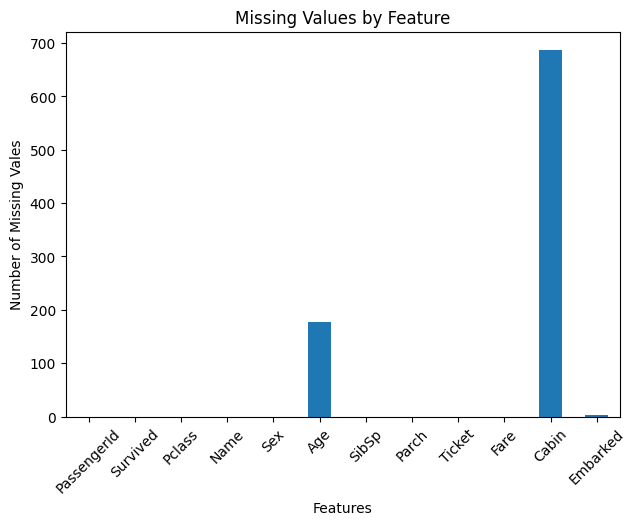

Duplicate rows :  0


In [47]:
missing = df.isnull().sum()

print(missing)

missing_percentage = (df.isnull().sum()/len(df))*100

missing_table = pd.DataFrame({
    "Missing Count" : missing,
    "Missing Percentage" : missing_percentage
})

display(missing_table)

plt.figure(figsize=(7.15,5))
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Vales")
plt.xticks(rotation=45)
plt.show()

print("Duplicate rows : ",df.duplicated().sum())

In [59]:
# Replacing msissing values by mean
df_mean = df.copy()

mean_age = df_mean['Age'].mean()

df_mean['Age'] = df_mean['Age'].fillna(mean_age)

print("Remaining missing Age values :",df_mean['Age'].isnull().sum())



# Replacing missing values by median
df_median = df.copy()

median_age = df_median['Age'].median()

df_median['Age'] = df_median['Age'].fillna(median_age)

print("\nRemaining missing Age values :",df_median['Age'].isnull().sum())


print("\nMean Age : ",df['Age'].mean())

print("\nMedian Age : ",df['Age'].median())



# Repplacing missing values by mode - not much suitable for numerical data
df_mode = df.copy()

mode_embarked = df_mode['Age'].mode()[0]

df_mode['Age'] = df_mode['Age'].fillna(mode_embarked)

print("\nRemaining missing Age values :",df_mode['Age'].isnull().sum())



# Replacing missing values by mode - Categorical data
df_mode = df.copy()

mode_embarked = df_mode['Embarked'].mode()[0]

df_mode['Embarked'] = df_mode['Embarked'].fillna(mode_embarked)

print("\nRemaining missing Embarked values :",df_mode['Embarked'].isnull().sum())

Remaining missing Age values : 0

Remaining missing Age values : 0

Mean Age :  29.69911764705882

Median Age :  28.0

Remaining missing Age values : 0

Remaining missing Embarked values : 0


In [82]:
# One-Hot-Encoder
display(df[['Sex','Embarked']].head(10))
print("\n")


from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder( sparse_output = False,
                        handle_unknown = 'ignore')

encoded = encoder.fit_transform(df[['Sex','Embarked']])

encoded_df = pd.DataFrame(encoded,
                          columns = encoder.get_feature_names_out(['Sex','Embarked']))

display(encoded_df.head())


print("\n")


# Label Encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Survived_encoded'] = le.fit_transform(df['Survived'])

display(df[['Survived','Survived_encoded']].head())

print("\n")

le1 = LabelEncoder()

df['Embarked_encoded'] = le.fit_transform(df['Embarked'])

display(df[['Embarked','Embarked_encoded']].head())

,Sex,Embarked
0,male,S
1,female,C
2,female,S
3,female,S
4,male,S
5,male,Q
6,male,S
7,male,S
8,female,S
9,female,C


,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,1.0,0.0


,Survived,Survived_encoded
0,0,0
1,1,1
2,1,1
3,1,1
4,0,0


,Embarked,Embarked_encoded
0,S,2
1,C,0
2,S,2
3,S,2
4,S,2


In [87]:
# Min-Max scaling
features = df[['Age','Fare']].dropna()

display(features.describe())

print("\n")

from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()

scaled_minmax = minmax.fit_transform(features)

minmax_df = pd.DataFrame(scaled_minmax,
                         columns = ['Age','Fare'])

display(minmax_df.head())

print("\n")


#Standardization
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()

scaled_standard = standard.fit_transform(features)

standard_df = pd.DataFrame(scaled_standard,
                         columns = ['Age','Fare'])

display(standard_df.head())


,Age,Fare
count,714.000000,714.000000
mean,29.699118,34.694514
std,14.526497,52.918930
min,0.420000,0.000000
25%,20.125000,8.050000
50%,28.000000,15.741700
75%,38.000000,33.375000
max,80.000000,512.329200


,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


,Age,Fare
0,-0.530377,-0.518978
1,0.571831,0.691897
2,-0.254825,-0.506214
3,0.365167,0.348049
4,0.365167,-0.503850
